# Linear regression 


# Theory

## 1. Machine Learning Workflow

The general process for training a supervised learning model:

$$\text{Training Set} \longrightarrow \text{Learning Algorithm} \longrightarrow \text{Hypothesis } h_\theta(x)$$

## 2. The Hypothesis Function

For linear regression, the hypothesis function $h_\theta(x)$ is defined as:

$$h_\theta(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_n x_n$$

Where $x_j$ is the $j$-th feature and $\theta_j$ is the $j$-th parameter. By defining a dummy feature $x_0 = 1$, we express this compactly:

\begin{align*}
h_\theta(x) &= \sum_{j=0}^{n} \theta_j x_j \\
&= \theta^T x
\end{align*}

Where $\theta$ and $x$ are $(n+1) \times 1$ column vectors:

\begin{align*}
\theta = \begin{bmatrix} \theta_0 \\ \theta_1 \\ \vdots \\ \theta_n \end{bmatrix}, \quad 
x = \begin{bmatrix} 1 \\ x_1 \\ \vdots \\ x_n \end{bmatrix}
\end{align*}

## 3. The Cost Function $J(\theta)$

To find optimal parameters such that $h_\theta(x) \approx y$, we minimize the Mean Squared Error (MSE) cost function:

$$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2$$

### Vectorized Form
Using matrix notation across all $m$ training examples:

$$J(\theta) = \frac{1}{2m} (X\theta - y)^T (X\theta - y)$$

* $X$: $m \times (n+1)$ design matrix
* $y$: $m \times 1$ target vector

## 4. Normal Equation Derivation

We solve for the analytical minimum by setting the gradient vector to zero: $\nabla_\theta J(\theta) = 0$.

### Gradient Vector
$$\nabla_\theta J(\theta) = \begin{bmatrix} \frac{\partial J}{\partial \theta_0} \\[6pt] \frac{\partial J}{\partial \theta_1} \\[6pt] \vdots \\[6pt] \frac{\partial J}{\partial \theta_n} \end{bmatrix}$$

### Step-by-Step Derivation

\begin{align*}
J(\theta) &= \frac{1}{2m} (X\theta - y)^T (X\theta - y) \\[6pt]
&= \frac{1}{2m} \left( (X\theta)^T - y^T \right) (X\theta - y) \\[6pt]
&= \frac{1}{2m} \left( \theta^T X^T X \theta - \theta^T X^T y - y^T X \theta + y^T y \right)
\end{align*}

Since $\theta^T X^T y$ is a scalar, it equals its transpose $y^T X \theta$. Combining like terms:

\begin{align*}
J(\theta) &= \frac{1}{2m} \left( \theta^T X^T X \theta - 2\theta^T X^T y + y^T y \right)
\end{align*}

Taking the gradient with respect to $\theta$ and setting it to zero:

\begin{align*}
\nabla_\theta J(\theta) &= \frac{1}{2m} \left( 2 X^T X \theta - 2 X^T y \right) \\[6pt]
&= \frac{1}{m} \left( X^T X \theta - X^T y \right) \\[10pt]
0 &= X^T X \theta - X^T y \\[6pt]
X^T X \theta &= X^T y \\[6pt]
\theta &= (X^T X)^{-1} X^T y
\end{align*}

# Probabilistic Interpretation

Assume the target is generated by a linear function plus noise:

$$y^{(i)} = \theta^T x^{(i)} + \varepsilon^{(i)}$$

where $\varepsilon^{(i)}$ captures unmodeled effects + random noise.

**Assumption:** the errors are i.i.d. Gaussian:

$$\varepsilon^{(i)} \sim \mathcal{N}(0, \sigma^2)$$

$$p\left(\varepsilon^{(i)}\right) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{\left(\varepsilon^{(i)}\right)^2}{2\sigma^2}\right)$$

This implies a distribution over $y^{(i)}$ given $x^{(i)}$, parameterized by $\theta$:

$$p\left(y^{(i)} \mid x^{(i)}; \theta\right) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{\left(y^{(i)} - \theta^T x^{(i)}\right)^2}{2\sigma^2}\right)$$

i.e. $\; y^{(i)} \mid x^{(i)}; \theta \sim \mathcal{N}\left(\theta^T x^{(i)}, \sigma^2\right)$ — note $\theta$ is **not** a random variable here; it parameterizes the mean.

### Likelihood of $\theta$

$$L(\theta) = p(\vec{y} \mid X; \theta)$$

Since the errors are i.i.d.:

$$L(\theta) = \prod_{i=1}^m p\left(y^{(i)} \mid x^{(i)}; \theta\right) = \prod_{i=1}^m \frac{1}{\sqrt{2\pi}\,\sigma} \exp\left(-\frac{\left(y^{(i)} - \theta^T x^{(i)}\right)^2}{2\sigma^2}\right)$$

### Log-likelihood

$$\ell(\theta) = \log L(\theta) = \log \prod_{i=1}^m \frac{1}{\sqrt{2\pi}\,\sigma}\exp(\cdots)$$

$$= \sum_{i=1}^m \left[\log \frac{1}{\sqrt{2\pi}\,\sigma} + \log \exp(\cdots)\right]$$

$$= m \log \frac{1}{\sqrt{2\pi}\,\sigma} + \sum_{i=1}^m -\frac{\left(y^{(i)} - \theta^T x^{(i)}\right)^2}{2\sigma^2}$$

### Maximum Likelihood Estimation (MLE)

MLE: choose $\theta$ to maximize $\ell(\theta)$.

Since the first term $m\log \frac{1}{\sqrt{2\pi}\sigma}$ doesn't depend on $\theta$, and the second term is $-\frac{1}{2\sigma^2}\sum (y^{(i)} - \theta^Tx^{(i)})^2$, maximizing $\ell(\theta)$ is equivalent to **minimizing**

$$\sum_{i=1}^m \left(y^{(i)} - \theta^T x^{(i)}\right)^2$$

## Implementation

I am going to use a salary data set to learn and demonstrate the key details about SLR.

In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn import datasets

## Data Analysis:

In [32]:
# first create the data fram for our data set 
df = pd.read_csv("Salary_dataset.csv")

#### Data Inspection:

In [33]:
# to look at how big our data set is
print(f"{df.shape} rows x columns")

(6000, 3) rows x columns


In [34]:
# to look at the first 5 data entries
df.head()

,ID,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [35]:
# check data types 
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               6000 non-null   int64  
 1   YearsExperience  6000 non-null   float64
 2   Salary           6000 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 140.8 KB


#### Data Cleaning

In [36]:
#check for any missing data points
print(df.isna().sum())

ID                 0
YearsExperience    0
Salary             0
dtype: int64


In [37]:
# rename columns, mainily to get rid of gaps and make all lower case. 
df.columns = df.columns.str.lower() # would add a .str.replace(' ', '_'), but our colun names have no gaps
df. rename(columns = {'yearsexperience' : 'experience',
                      'unnamed: 0' : 'id'
}, inplace = True)  #inplace tells pandas to change the exisitng copy rater then create a new one

In [38]:
df.head()

,id,experience,salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


## Regression analysis

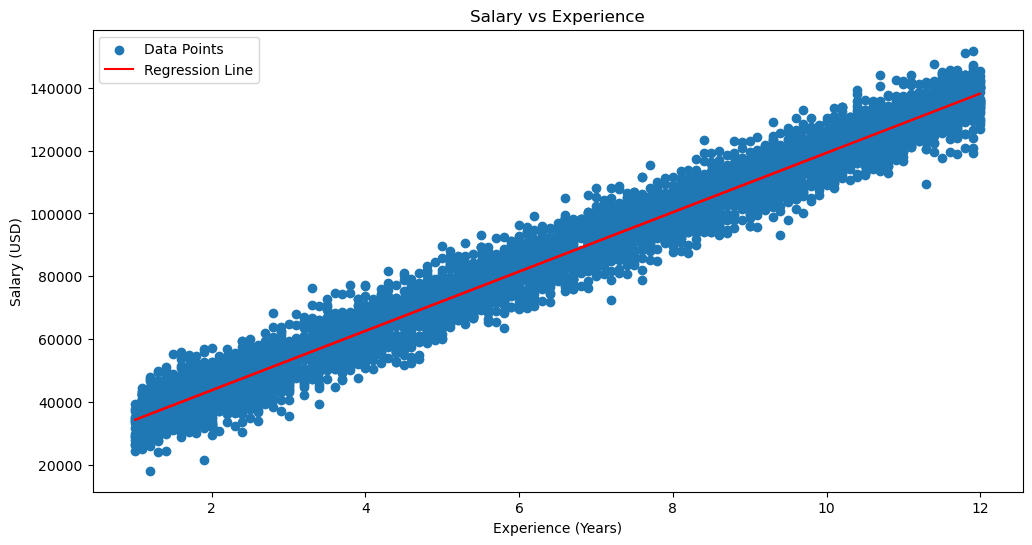

In [39]:
fig, axe = plt.subplots(1, 1, figsize=(12,6))

axe.scatter(df.experience, df.salary, label='Data Points')

m, b = np.polyfit(df.experience, df.salary, 1)
axe.plot(df.experience, m * df.experience + b, color='red', label='Regression Line')

# 4. Format the chart
axe.set_xlabel("Experience (Years)")
axe.set_ylabel("Salary (USD)")
axe.set_title("Salary vs Experience")
axe.legend()

plt.show()

## Building a Linear Regression Model

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

### Define X,Y Matrices and Split the Data

In [46]:
X = df[['experience']]    # for sklearn, we need to use double brackets, as sk learn needs a 2d aray
y = df[['salary']]

In [47]:
# gives row x col using sklearn package  
X.shape, y.shape

((6000, 1), (6000, 1))

In [48]:
#splits into trianing and testing
X_train, X_test, y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

### Import and Initialize the Model

In [49]:
# creates a blank model ready to learn 
model = LinearRegression()

# train model using X,y trianing data
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [50]:
# Ask the model to predict salaries for the test set
predictions = model.predict(X_test)

# Let's look at the first 5 predictions compared to the actual salaries
print("Predicted Salaries:", predictions)
print("Actual Salaries:   ", y_test.values)

Predicted Salaries: [[ 35317.63767896]
 [100409.03061244]
 [127766.28271491]
 ...
 [ 86258.72780081]
 [128709.63623569]
 [126822.92919414]]
Actual Salaries:    [[ 34617. ]
 [106210.3]
 [121872. ]
 ...
 [ 91839.3]
 [131321.1]
 [121438.5]]


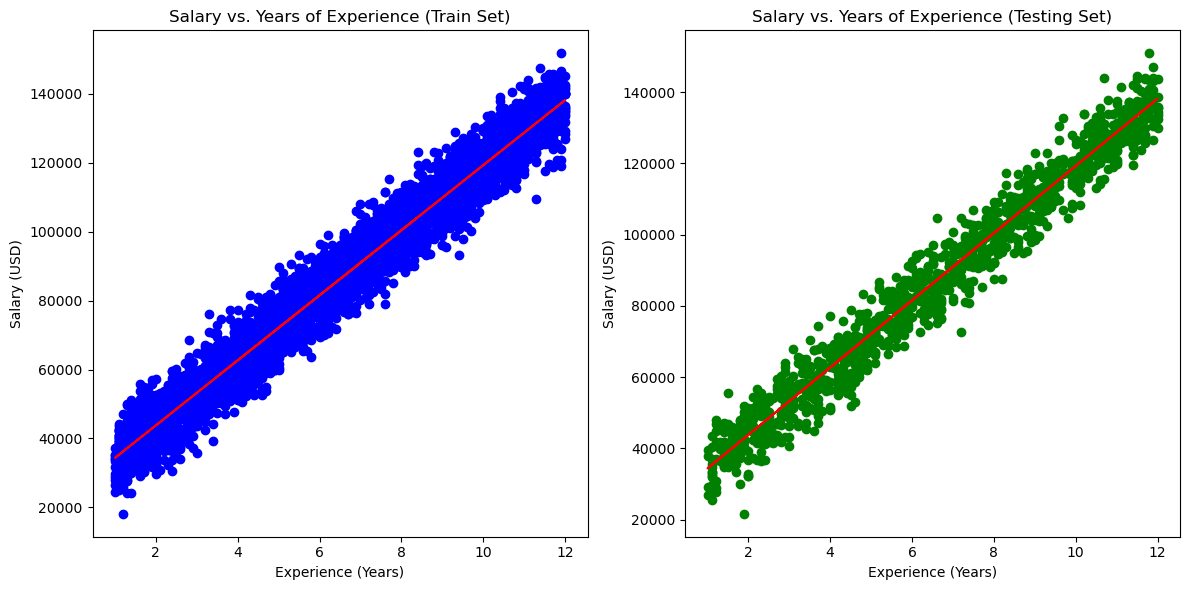

In [51]:

fig, axes = plt.subplots(1,2,figsize=(12, 6))

axes[1].scatter(X_test, y_test, color='green', label='Actual Salaries (Test Data)')
axes[1].plot(X_train, model.predict(X_train), color='red', label='Regression Line')
axes[1].set_title("Salary vs. Years of Experience (Testing Set)")
axes[1].set_xlabel("Experience (Years)")
axes[1].set_ylabel("Salary (USD)")

axes[0].scatter(X_train, y_train, color='Blue', label='Actual Salaries (Train Data)')
axes[0].plot(X_train, model.predict(X_train), color='red', label='Regression Line')
axes[0].set_title("Salary vs. Years of Experience (Train Set)")
axes[0].set_xlabel("Experience (Years)")
axes[0].set_ylabel("Salary (USD)")

plt.tight_layout()
plt.show()

## Evaluate the Good fit of the model

In [52]:
r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

# NumPy is used here to find the square root of the MSE
rmse = np.sqrt(mean_squared_error(y_test, predictions)) 

print(f"R-Squared: {r2:.3f}")
print(f"MAE: ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")

R-Squared: 0.965
MAE: $4,576.30
RMSE: $5,709.48


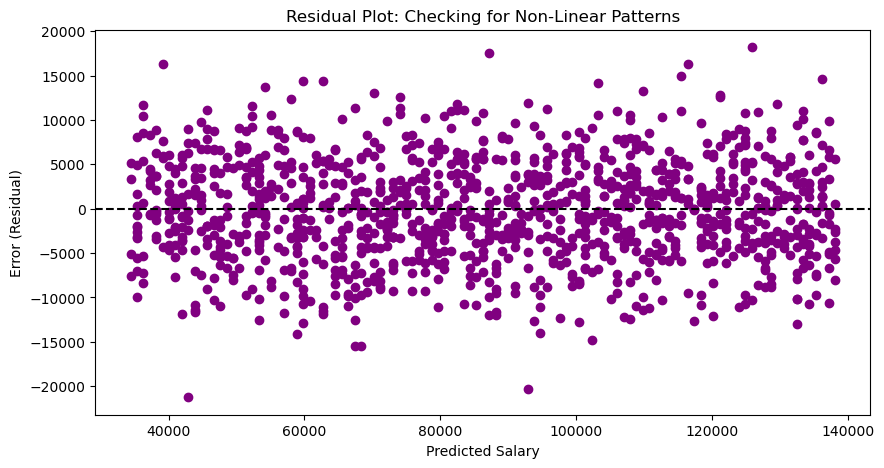

In [53]:
# Calculate the residuals 
residuals = y_test.values - predictions

# Plot predictions vs. residuals
plt.figure(figsize=(10, 5))
plt.scatter(predictions, residuals, color='purple')
plt.axhline(y=0, color='black', linestyle='--') # Draws a baseline at zero error
plt.title("Residual Plot: Checking for Non-Linear Patterns")
plt.xlabel("Predicted Salary")
plt.ylabel("Error (Residual)")
plt.show()